# Day 28b: SVM Extra Practice

Extra practice — Breast Cancer dataset, non-linear data (moons), aur SVR (regression).

## Import Libraries

# Day 28b: SVM Extra PracticeExtra practice — Breast Cancer dataset, non-linear data (moons), aur SVR (regression).

## Load Breast Cancer Dataset

## Import Libraries

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

## Load Breast Cancer Dataset

In [9]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()

## Train-Test Split

In [10]:
data

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]], shape=(569, 30)),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,

## Feature Scaling

In [11]:
feature_names=data.feature_names

In [15]:
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target   # 0 = malignant, 1 = benign

## Train-Test Split

## Hard Margin vs Soft Margin SVM

C=1000 (hard margin) vs C=0.1 (soft margin) compare.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Feature Scaling

In [17]:
scaler=StandardScaler()

In [18]:
X_train_scaled=scaler.fit_transform(X_train)

In [19]:
X_test_scaled=scaler.transform(X_test)

## Non-linear Data — Make Moons

## Hard Margin vs Soft Margin SVMC=1000 (hard margin) vs C=0.1 (soft margin) compare.

In [20]:
svm_hard = SVC(kernel='linear', C=1000, random_state=42)
svm_soft = SVC(kernel='linear', C=0.1, random_state=42)

In [21]:
svm_hard.fit(X_train_scaled,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1000
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [22]:
svm_soft.fit(X_train_scaled,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",0.1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [23]:
print("Hard margin (C=1000) accuracy:", accuracy_score(y_test, svm_hard.predict(X_test_scaled)))
print("Soft margin (C=0.1) accuracy:", accuracy_score(y_test, svm_soft.predict(X_test_scaled)))

Hard margin (C=1000) accuracy: 0.9298245614035088
Soft margin (C=0.1) accuracy: 0.9824561403508771


## Kernel Comparison on Moons

In [24]:
print("Support vectors (hard margin):", svm_hard.support_vectors_.shape[0])
print("Support vectors (soft margin):", svm_soft.support_vectors_.shape[0])

Support vectors (hard margin): 24
Support vectors (soft margin): 51


## Non-linear Data — Make Moons

In [28]:
from sklearn.datasets import make_moons

## GridSearchCV on Moons

In [29]:
X_moons, y_moons = make_moons(n_samples=300, noise=0.15, random_state=42)


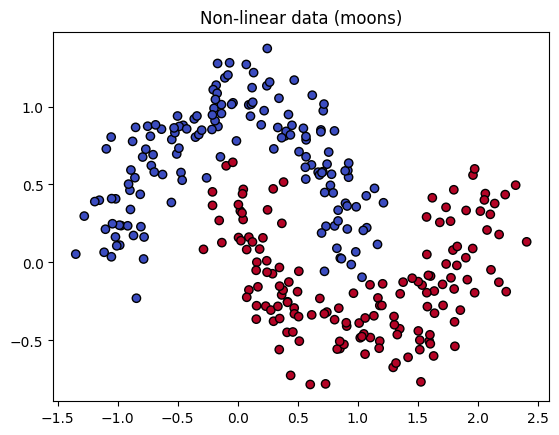

In [32]:
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='coolwarm', edgecolors='k')
plt.title("Non-linear data (moons)")
plt.show()

In [33]:
Xm_train, Xm_test, ym_train, ym_test = train_test_split(X_moons, y_moons, test_size=0.2, random_state=42, stratify=y_moons)

scaler_m = StandardScaler()
Xm_train_scaled = scaler_m.fit_transform(Xm_train)
Xm_test_scaled = scaler_m.transform(Xm_test)

In [34]:
kernels=['linear','poly','rbf']

## Kernel Comparison on Moons

## Support Vector Regression (SVR)

SVM regression ke liye bhi use hota hai.

In [38]:
for k in kernels:
    model=SVC(kernel=k,random_state=42)
    model.fit(Xm_train_scaled,ym_train)
    acc=accuracy_score(ym_test,model.predict(Xm_test_scaled))
    print(f"{k} kernel accuracy: {acc:.4f}")

linear kernel accuracy: 0.8000
poly kernel accuracy: 0.8000
rbf kernel accuracy: 0.9667


In [39]:
for g in [0.1, 1, 10]:
    model = SVC(kernel='rbf', gamma=g, random_state=42)
    model.fit(Xm_train_scaled, ym_train)
    acc = accuracy_score(ym_test, model.predict(Xm_test_scaled))
    print(f"gamma={g}: accuracy={acc:.4f}")

gamma=0.1: accuracy=0.8000
gamma=1: accuracy=0.9833
gamma=10: accuracy=0.9667


## SVR on Tips Dataset

In [40]:
param_grid = {'C': [0.1, 1, 10, 100], 'gamma': [0.001, 0.01, 0.1, 1], 'kernel': ['rbf']}

## GridSearchCV on Moons

In [41]:
grid_search=GridSearchCV(SVC(random_state=42),param_grid,cv=5,scoring='accuracy')

In [45]:
grid_search.fit(X_train_scaled,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(random_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'gamma': [0.001, 0.01, ...], 'kernel': ['rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displaye

In [46]:
print("Best params:", grid_search.best_params_)
print("Best CV accuracy:", grid_search.best_score_)

Best params: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
Best CV accuracy: 0.9802197802197803


In [47]:
best_svm = grid_search.best_estimator_
test_acc = accuracy_score(y_test, best_svm.predict(X_test_scaled))
print("Test accuracy:", test_acc)

Test accuracy: 0.9824561403508771


In [48]:
from sklearn.svm import SVR

## Support Vector Regression (SVR)SVM regression ke liye bhi use hota hai.

In [49]:
from sklearn.metrics import mean_squared_error, r2_score

In [50]:
tips = sns.load_dataset('tips')
X_tips = tips[['total_bill', 'size']]
y_tips = tips['tip']

Xt_train, Xt_test, yt_train, yt_test = train_test_split(X_tips, y_tips, test_size=0.2, random_state=42)

## SVR on Tips Dataset

In [51]:
scaler_t = StandardScaler()
Xt_train_scaled = scaler_t.fit_transform(Xt_train)
Xt_test_scaled = scaler_t.transform(Xt_test)

In [52]:
svr = SVR(kernel='rbf', C=1.0, epsilon=0.1)
svr.fit(Xt_train_scaled, yt_train)
pred = svr.predict(Xt_test_scaled)

In [53]:
print("SVR MSE:", mean_squared_error(yt_test, pred))
print("SVR R2:", r2_score(yt_test, pred))

SVR MSE: 0.5726930876212424
SVR R2: 0.5418350270291568
